# **Customer Churn Analysis and Retention Strategies in Banking**
# **1. Project Objective**:
The objective of this project is to perform an analysis of customer data to
understand the key factors influencing customer churn in a Banking sector. Customer churn refers to the phenomenon where customers stop doing business with a company.

The project aims to:
  1. Identify patterns and trends in customer behavior
  2. Analyze the impact of demographic and financial factors on churn
  3. Use data visualization techniques to uncover insights
  4. Provide actionable recommendations to improve customer retention.

# **2. Dataset Overview**
The dataset contains customer information including demographics, account detains and churn status.





In [35]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#load dataset
from google.colab import files
uploaded=files.upload()

Saving Bank_Churn.csv to Bank_Churn (1).csv


The Pandas library is imported to handle and analyze the data structure. It provides functions to read, manipulate and process datasets. The alias **pd** is used as a standard shorthand for convenience. While Numpy is used to support numerical operations. Matplotlib and Seaborn libraries were imported to create visual representation of the Dataset. Matplotlib provides function for generating graphs and customizing visual elements such as titles and labels, while Seaborn offers advanced statistical visualization with improved presentation and readability. The **files** module from google colab is used to upload dataset from the local module into working environment. The **files.upload()** function helps the user to select and upload the dataset.

In [36]:
df=pd.read_csv("Bank_Churn.csv")

The dataset was loaded using the **read_csv** function from pandas library. which is used to read the dataset file in csv format and converts it into a DataFrame. The DataFrame is stored in a variable named df, which helps to easy analysis of the dataset.

In [37]:
#view first five rows
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


The **head()** function is used to display first five rows of the dataset. It helps understanding the structure, column names and initial values of the dataset.

In [38]:
#shape of dataset
df.shape

(10000, 13)

The **shape** attribute is used to display the number of rows and columns in the dataset. It helps in understanding the overall structure of the dataset.

In [39]:
#column names
df.columns

Index(['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age',
       'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited'],
      dtype='object')

The **columns** attribute is used to determine the all the column names in the datset. It helps for viewing, modifying, or creating new column labels for a DataFrame.

In [40]:
#data types and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


The **info()** function provides summary of the dataset including column names, datatypes,memeory usage and the non-null counts. It is useful for identifying missing values and structure of the dataset.

In [41]:
#statistical summary
df.describe()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


The **describe()** function provides statistical details of the numerical columns such as mean,minimum,maximum and standard deviation. This helps in understanding the distribution and variation of data.

**Observations**:


*   The dataset contains multiple numerical and categorical features
*   No. of rows: 10000
*   No. of columns: 13
*   Data includes customer demographics, account balance, and activity status.



# **3. Data Pre-processing**
Data cleaning and handling is a crucial step before analyis.



In [42]:
#removing unnecessary columns
df=df.drop(columns=["CustomerId","Surname"])

The **drop()** function used to remove unnecessary columns or rows from the dataset. To remove unwanted columns, we use the **columns=[** along with drop. The columns such as CustomerId and Surname were removed as they don't contribute to the analysis of customer churn. Removing them simplifies the dataset and improves the efficiency of analysis.

In [43]:
#check missing values
df.isnull().sum()

,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0


The **isnull()** function was used to identify missing values in a dataset, and the **sum()** function used to count them. The result showed that there is no missing values in the dataset , indicating that the datset is complete and it doesn't require any further handling.

In [46]:
#checking for duplicates
df.duplicated().sum()

np.int64(0)

The **duplicated()** function was used to identify duplicate entries in the dataset, and the **sum()** function counted the number of such duplicates. The result showed that there is no duplicate records. So, no further action required. It assures accuracy and reliability of the dataset.

In [47]:
#datatype checking
df.dtypes

,0
CreditScore,int64
Geography,object
Gender,object
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64
HasCrCard,int64
IsActiveMember,int64
EstimatedSalary,float64


The **dtypes** attribute was used to check the datatype of each column in the dataset to verify each column has the correct format. It was observed that all the columns have appropriate datatype, with numerical variables stored as integers or float and categorical variables were stored as object type. Therefore, no datatype conversion was required.

In [48]:
#derived columns
df["Balance Category"]= "Zero"
df.loc[df["Balance"] >0, "Balance Category"]= "Low"
df.loc[df["Balance"] >50000, "Balance Category"]= "Medium"
df.loc[df["Balance"] >150000, "Balance Category"]= "High"



In [49]:
df["Age group"]= "Young"
df.loc[df["Age"] >30, "Age group"]= "Adult"
df.loc[df["Age"] >45, "Age group"]= "Middle age"
df.loc[df["Age"] >60, "Age group"]= "Senior"

New features were created using existing variables to simplify analysis. Age was grouped into different life stages such as Young, Adult, Middle age, Senior and Balance was categorised into levels such as Zero, Low, Medium and High. These derived column helps in identifying patterns more clearly during analysis.

In [ ]:
#filtering
exited_customers=df[df["Exited"]==1]

This filters the datset to include only customers who have exited the bank. The condition **Exited==1** select who have churned the bank.

In [50]:
active_customers=df[df["IsActiveMember"]==1]

This filters the datset to include only active customers. The condition **IsActiveMember==1** select who are active.

In [52]:
high_balance=df[df["Balance"]>100000]

This filters the customers with a balance greater than 100000. It helps in analysis of high-value customers.

# **4. Exploratory Data Analysis (EDA)**
EDA is performed to understand patterns, relationships, and trends in the dataset.



**4.1**  **Univariate analysis** :
This analysis focuses on understanding the distribution of individual variables.



In [ ]:
df["Geography"].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


The **value_counts()** function counts the number of customers by geography, showing distribution across regions.

In [ ]:
df["Age"].describe()

,Age
count,10000.000000
mean,38.921800
std,10.487806
min,18.000000
25%,32.000000
50%,37.000000
75%,44.000000
max,92.000000


The **describe()** function was used to generate statistical summaries of the Age column, including mean,minimum,maximum and quartile values.
The average customer age is 39 years, indicating that most of the customers are belongs to middle-age category. The age distribution ranges from 18-92 years, shows that the bank serves customers across wide age range. The standard deviation indicates moderate variation in customer ages. The quartile values are indicating 25% customers are below 32, 50%customers are below 37 and 75% customers are below 44.

In [ ]:
df["Exited"].value_counts()

,count
Exited,
0,7963
1,2037


This analysis was conducted to determine the count of customers who exited compared to those who remained. The results indicate that the number of customers who stayed is significantly higher than those who churned.

**4.2 Bi-Variate Analysis**

In [ ]:
#aggregation
df.groupby("Geography")["Balance"].mean()


,Balance
Geography,
France,62092.636516
Germany,119730.116134
Spain,61818.147763


The **groupby()** function groups data based on Geography. The **mean()** calculates the average balance of customers in each country, helping regional wise caluculations.

In [ ]:
df.groupby("Gender")["Exited"].sum()

,Exited
Gender,
Female,1139
Male,898


The **groupby()** function groups data based on Gender. And calculates the total number of customers who exited. It helps in comparison of churn between male and female.

In [ ]:
df.groupby("Exited")["EstimatedSalary"].mean()

,EstimatedSalary
Exited,
0,99738.391772
1,101465.677531


This calculates the average salary of customers who exited and those who stayed, helping identify income-related trends.

In [ ]:
df.groupby("Age group")["Exited"].mean()

,Exited
Age group,
Adult,0.157406
Middle age,0.511233
Senior,0.247845
Young,0.075203


This analysis groups customers by Age group and calculates average churn rate, helping identify which age group is more likely to churn.

**4.3** **Multivariate analysis**

In [ ]:
df.groupby(["Geography","Gender"])["Exited"].mean()

Geography  Gender
France     Female    0.203450
           Male      0.127134
Germany    Female    0.375524
           Male      0.278116
Spain      Female    0.212121
           Male      0.131124
Name: Exited, dtype: float64

The dataset was grouped by Geography, Gender and mean of the Exited column was calculated. Since the Exited column contains binary values (1 for exited and 0 for retained customers), the mean represents the churn rate for each customer group.
The analysis helps identify which combinations of Geography and Gender have high churn rates. Higher mean value indicates a greater proportion of customer leaving the bank.

In [ ]:
df.groupby(["Age group","Gender"])["Balance"].mean()

Age group   Gender
Adult       Female    75218.719018
            Male      77058.329098
Middle age  Female    80932.225255
            Male      82066.666715
Senior      Female    75645.965117
            Male      75824.598247
Young       Female    72053.228057
            Male      74125.300515
Name: Balance, dtype: float64

The dataset was grouped by Agegroup, Gender and mean function was applied to  the balance column to calculate average account balance for each category. This multivate analyis helps compare financial pattern among different customer groups based on both age category and gender. Higher mean value indicates customer group with large average balances, while lower value indicate comparatively smaller balances. These insight can help the bank understand customer financial capabilities and identify valuable customer segments more effectively.

**4.4 Pivot Table**

In [ ]:
pd.pivot_table(df,values="Balance",index="Geography",columns="Gender",aggfunc="mean")

Gender,Female,Male
Geography,,
France,60322.670159,63546.284875
Germany,119145.966471,120259.668222
Spain,59862.092534,63352.833746


A pivot table was created to analyze average account balance for different geographical regions and genders. The **pivot table ()** function summarizes the dataset by grouping records based on geography and gender, while the mean() aggregate function calculate the average balance for each category combination. Higher mean value indicate customer group with strong financial holdings. This analysis supports better understanding of demographic and regional financial behaviour within the bank.

**4.5** **Correlation Analysis**

In [ ]:
numeric_df=df.select_dtypes(include=["int64","float64"])
numeric_df.corr()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
CreditScore,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
Age,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
Tenure,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001
Balance,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
NumOfProducts,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
HasCrCard,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138
IsActiveMember,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128
EstimatedSalary,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097
Exited,-0.027094,0.285323,-0.014001,0.118533,-0.047820,-0.007138,-0.156128,0.012097,1.000000


The **select_dtypes()** function was used to extract numerical variables from the dataset. Correlation analysis requires numerical values variables because relationships cannot be calculated directly on categorical text data. The **corr**() function was applied to calculate the relationship among these variables. Correlation values ranges between -1 and +1, where positive values indicate direct relationships, negative values indicate inverse relationships, and values near zero indicate weak relationships.
Analysis: The correlation analysis showed that Age has the strongest positive relationship with customer churn(0.285), suggesting that older customers may have a higher tendency to leave the bank. Balance also showed a weak positive relationship with churn(0.119). IsActiveMember displayed a negative relationship (-0.156), indicating that active customers are less likely to exit the bank. Variables such as Creditscore, Tenure and Estimatedsalary showed very weak correlations, suggesting limited influence on customer churn behaviour.

# **5** **Visualizations**
The project includes multiple visualizations such as:
*   Bar chart
*   Histogram
*   Box plot
*   Scatter plot
*   Heatmap









**Bar plot (Customer Churn Distribution**)

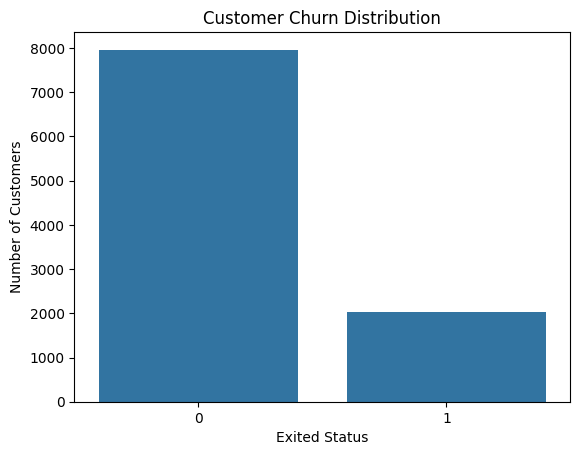

In [ ]:
sns.countplot(x="Exited",data=df)
plt.title("Customer Churn Distribution")
plt.xlabel("Exited Status")
plt.ylabel("Number of Customers")
plt.show()

  Countplot() used to visualize the distribution of customer churn in the dataset. The graph compares customer who remained with those who exited the bank.
  The visualization helps identify the proportion of customers who stayed versus those who left the bank. If retained customers are significantly higher than the churned customers, it indicates that the customer retention is stronger than customer loss.

**Histogram (Age distribution)**

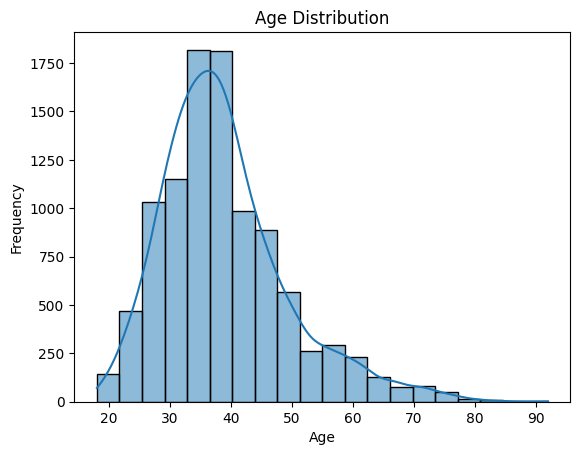

In [ ]:
sns.histplot(df["Age"],bins=20,kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

A histogram was created to visualize the distribution of customer ages in the dataset. The X-axis represents customer age, while the Y-axis represents frequency, which indicates the number of customers within each age range. The **bins** parameter grouped customers ages into intervels, and **kde=True** added a smooth density curve to show the overall pattern of age distribution. The histogram shows that the majority of customers fall within the age range of approximately **30-40 years**, indicating that middle-aged customers form the largest customer segment of the bank. The number of customers gradually decreases at higher age ranges, with relatively few customers above **70years**. The age distribution appears slightly right-skewed, suggesting a larger concentration of younger and middle-aged customers compared to senior customers.

**Pie Chart (Gender Distribution)**

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

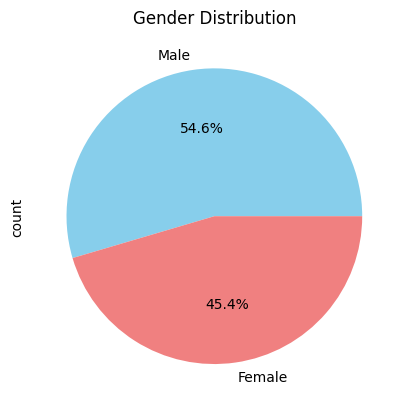

In [ ]:
df["Gender"].value_counts().plot(kind="pie",autopct="%1.1f%%",colors=["skyblue","lightcoral"])
plt.title("Gender Distribution")
plt

A pie chart was created to visualise the gender distribution of customers in the dataset. The **value_counts()** function was used to count the number of customers in each gender category, while the **plot(kind="pie")** displayed the proportions as percentage. The **autopct="%1.1f%%"** parameter was used to display percentage values within the chart. The pie chart indicates that the customer population is relatively balanced between male and female customers. Male customer represent approximately **54.6%**  of the dataset, while the female customers account for **45.4%**. The results show a slightly higher proportion of male customers, although the difference isn't substantial. This suggests that the bank serves customers from both genders fairly evenly without significant dominance of one group.

**Box Plot (Balance Distribution)**

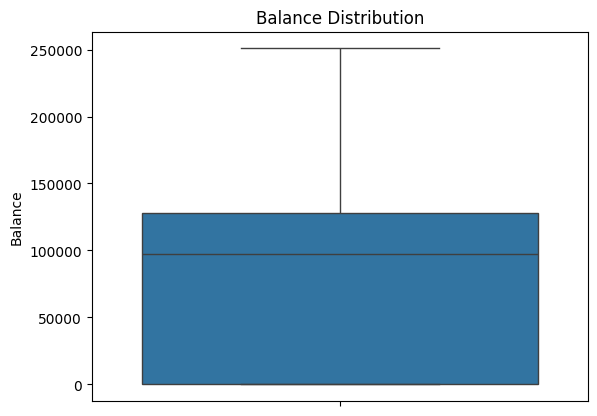

In [ ]:
sns.boxplot(y="Balance",data=df)
plt.title("Balance Distribution")
plt.ylabel("Balance")
plt.show()

The boxplot illustrates the distribution of customer balance. It shows the median balance, interquartile range, and presence of outliers. The data appears to have a wide spread, indicating variability in customer balances. Several outliers are observed, suggesting that some customers maintain significantly higher balances than others.

**Scatterplot**

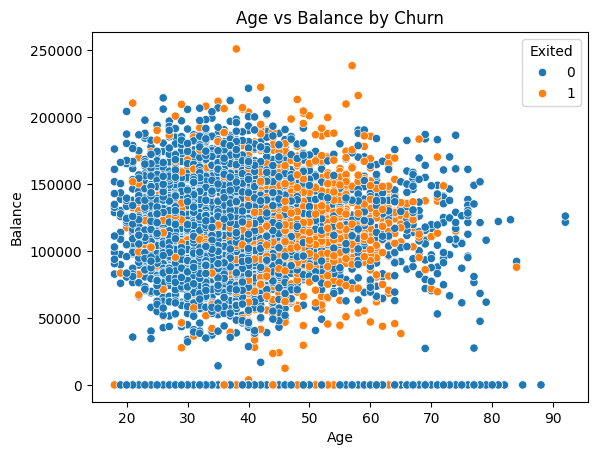

In [ ]:
sns.scatterplot(x="Age",y="Balance",hue="Exited",data=df)
plt.title("Age vs Balance by Churn")
plt.show()

 The scatterplot shows no strong relationship between age and balance, as values are widely distributed across all age groups. When considering churn, both churned and non-churned customers overlap significantly, indicating no clear separation. However, there is a slight concentration of churned customers in higher age ranges, suggesting a weak tendency rather than a strong pattern.

**Heatmap**

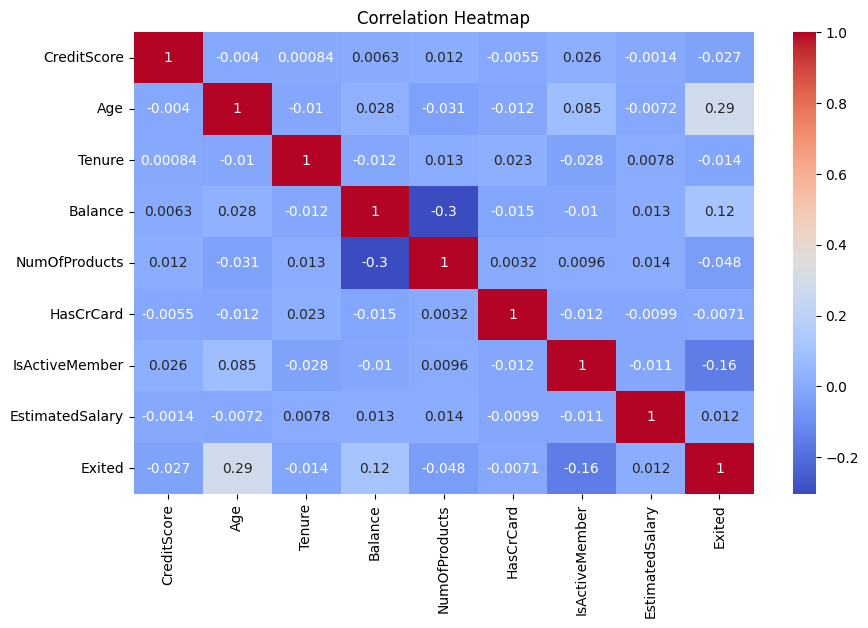

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap presents the relationships between all numerical variables in the dataset using correlation coefficients. The values range from -1 to +1, where values closer to +1 indicate a strong positive relationship, values closer to -1 indicate a strong negative relationship, and values near zero indicate weak or no linear relationship. From the heatmap, most variables show weak to moderate correlations with each other, suggesting that there is no strong multicollinearity in the dataset. The target variable (Exited) shows only low to moderate correlation with other features, indicating that no single variable strongly influences customer churn. This suggests that churn behavior is likely driven by a combination of multiple factors rather than one dominant variable.


# **Key insights**

* The analysis reveals that customer churn is not driven by a single dominant factor but is influenced by a combination of variables.
* The scatterplot analysis shows no strong relationship between age and balance, and no clear separation between churned and non-churned customers, indicating that these variables alone are insufficient to explain churn behavior.

* The boxplot highlights a wide variation in customer balances, suggesting diversity in customer financial profiles, but does not establish a direct link to churn.

* The correlation heatmap further supports this by showing only weak to moderate relationships among variables, with no strong correlation with the target variable. However, a slight tendency of higher churn among older customers is observed, indicating that age may have a minor influence.
* Overall, churn appears to be a complex, multi-factor phenomenon.








# **Recommendations**

Based on the analysis, businesses should adopt a multi-dimensional approach to reduce customer churn. Since no single variable strongly predicts churn, organizations should implement predictive analytics models that combine multiple features to identify at-risk customers. Special attention should be given to older customers, as they show a slightly higher tendency to churn, and targeted retention strategies such as personalized financial services and loyalty programs can be introduced. Customer engagement should be enhanced through regular communication, feedback mechanisms, and tailored offers to improve satisfaction. Additionally, high-value customers should be prioritized with premium services to ensure retention. A proactive monitoring system should also be implemented to detect early signs of churn and take timely action.



# **Conclusion**

In conclusion, the analysis demonstrates that customer churn is a complex issue influenced by multiple interacting factors rather than a single variable. While variables such as age and balance provide some insights, they do not independently determine churn behavior. The absence of strong correlations and clear visual separation between churned and non-churned customers highlights the need for a comprehensive, data-driven approach. By leveraging predictive analytics, improving customer engagement, and focusing on targeted retention strategies, organizations can effectively reduce churn and enhance long-term customer value.

